In [1]:
import torch 
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn 
import torch.functional as F 
import torch.optim as optim     

import lightning as L
from lightning.pytorch.loggers import TensorBoardLogger
tb_logger = TensorBoardLogger(
    save_dir="lightning_logs",
    name="lightning_nn"
)



import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline 

from sklearn.model_selection import train_test_split

torch.manual_seed(42)

W0721 17:40:25.390000 30792 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
torch.set_float32_matmul_precision("high")

# DATA MANAGEMENT

In [4]:
df = pd.DataFrame(pd.read_csv(r'datasets/fmnist_small.csv'))

X = df.iloc[:,1:].values
y = df.iloc[:, 0].values

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# scaling : 
X_train = X_train/255
X_test = X_test/255

X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]], shape=(4800, 784))

In [7]:
class CustomDataset(Dataset) :

    def __init__(self, features, labels):
        
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype= torch.long )

    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        
        return self.features[index], self.labels[index]

In [8]:
dataset_train = CustomDataset(X_train, y_train)
dataset_test = CustomDataset(X_test, y_test)

dataLoader_train = DataLoader(dataset_train, batch_size = 32, shuffle=True,  pin_memory=True )
dataLoader_test = DataLoader(dataset_test, batch_size = 32, shuffle=True,  pin_memory=True )

In [9]:
len(dataLoader_train)

150

# making NN 

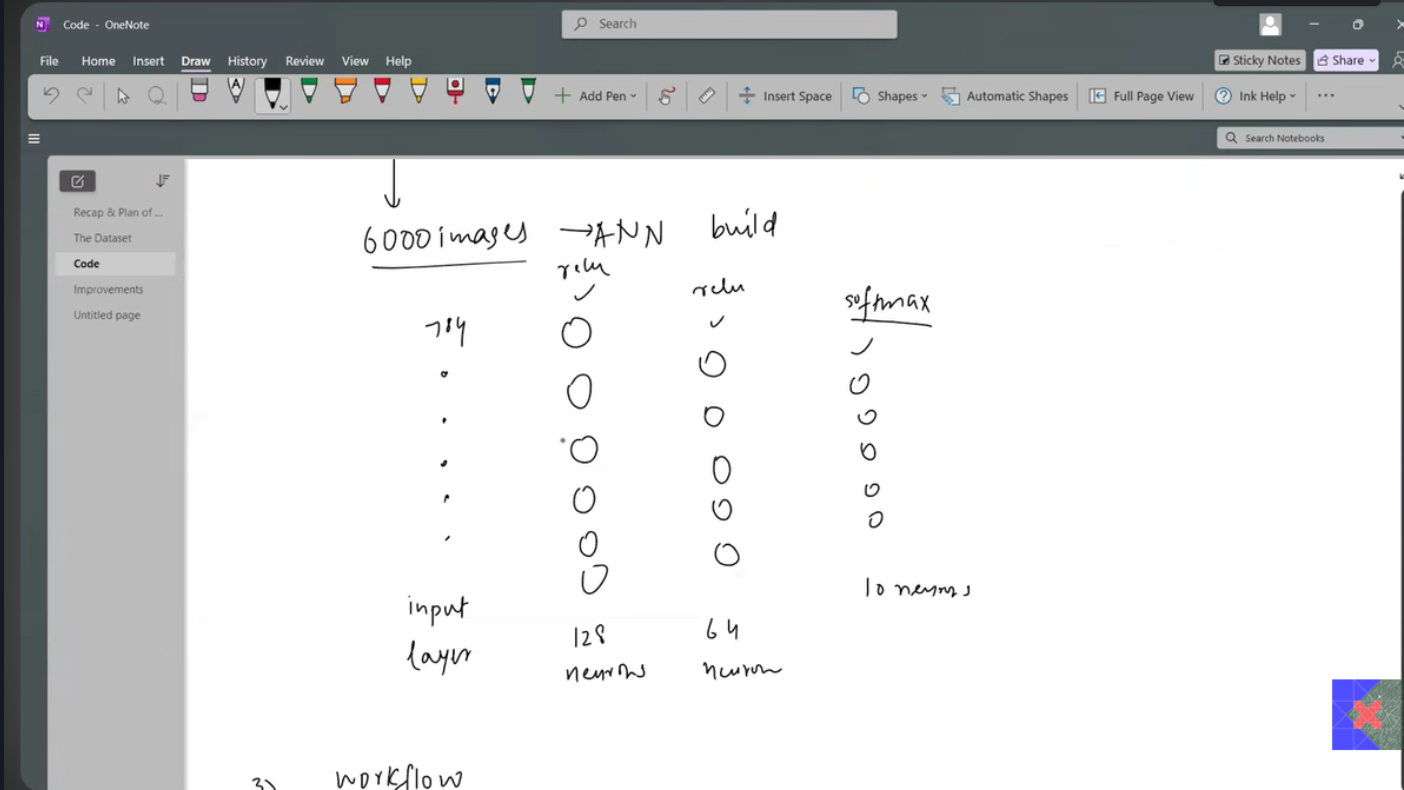

In [10]:
class nnClass(L.LightningModule) :

    def __init__(self):
        super().__init__()

        self.loss_f = nn.CrossEntropyLoss()
        self.lr = 0.1

        self.net = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)

        )

    def forward(self, input):
        return self.net(input)
    
    def configure_optimizers(self):
        return optim.SGD(self.parameters(), self.lr)
    
    def training_step(self, batch, batch_index):

        input_i, label_i = batch
        # print("inputs:", input_i.shape)
        # print("labels:", label_i.shape)
        # print("first input:", input_i[0].shape)

        pred_i = self.forward(input_i)
        
        # print("predictions:", pred_i.shape)

        loss = self.loss_f(pred_i, label_i)

        predicted_classes = pred_i.argmax(dim=1)
        accuracy = (predicted_classes == label_i).float().mean()

        self.log(
            "train_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True
        )

        self.log(
            "train_accuracy",
            accuracy,
            on_step=False,
            on_epoch=True,
            prog_bar=True
        )

        return loss

In [11]:
model = nnClass()
trainer = L.Trainer(
                    accelerator='gpu',
                    max_epochs = 100, 
                    log_every_n_steps=5, 
                    devices='auto',
                    logger=tb_logger)


trainer.fit(model,train_dataloaders=dataLoader_train)

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name   | Type             | Params | Mode  | FLOPs
------------------------------------------------------------
0 | loss_f | CrossEntropyLoss | 0      | train | 0    
1 | net    | Sequential       | 109 K  | train | 0    
------------------------------------------------------------
109 K     Trainable params
0         Non-trainable params
109 K     Total params
0.438     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode
0

Epoch 99: 100%|██████████| 150/150 [00:00<00:00, 253.67it/s, v_num=1, train_loss=0.00467, train_accuracy=1.000]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 150/150 [00:00<00:00, 251.13it/s, v_num=1, train_loss=0.00467, train_accuracy=1.000]


In [19]:
# ACCURACY OF TRAINING DATA 

total_preds = 0
correct_preds = 0 

with torch.no_grad() :
    batch_count = 0
    for feature_batch, label_batch in dataLoader_train :

        pred_batch = model(feature_batch)
        predicted_classes_batch = pred_batch.argmax(dim=1)

        total_preds += predicted_classes_batch.shape[0]
        correct_preds += (predicted_classes_batch == label_batch).sum().item()

        print(f"AVG accuracy for batch {batch_count} : {correct_preds/total_preds} ")
        batch_count+=1

AVG accuracy for batch 0 : 1.0 
AVG accuracy for batch 1 : 1.0 
AVG accuracy for batch 2 : 1.0 
AVG accuracy for batch 3 : 1.0 
AVG accuracy for batch 4 : 1.0 
AVG accuracy for batch 5 : 1.0 
AVG accuracy for batch 6 : 1.0 
AVG accuracy for batch 7 : 1.0 
AVG accuracy for batch 8 : 1.0 
AVG accuracy for batch 9 : 1.0 
AVG accuracy for batch 10 : 1.0 
AVG accuracy for batch 11 : 1.0 
AVG accuracy for batch 12 : 1.0 
AVG accuracy for batch 13 : 1.0 
AVG accuracy for batch 14 : 1.0 
AVG accuracy for batch 15 : 1.0 
AVG accuracy for batch 16 : 1.0 
AVG accuracy for batch 17 : 1.0 
AVG accuracy for batch 18 : 1.0 
AVG accuracy for batch 19 : 1.0 
AVG accuracy for batch 20 : 1.0 
AVG accuracy for batch 21 : 1.0 
AVG accuracy for batch 22 : 1.0 
AVG accuracy for batch 23 : 1.0 
AVG accuracy for batch 24 : 1.0 
AVG accuracy for batch 25 : 1.0 
AVG accuracy for batch 26 : 1.0 
AVG accuracy for batch 27 : 1.0 
AVG accuracy for batch 28 : 1.0 
AVG accuracy for batch 29 : 1.0 
AVG accuracy for bat

# Testing DATA PREDICTIONS 

In [20]:
total_preds = 0
correct_preds = 0 

with torch.no_grad() :
    batch_count = 0
    for feature_batch, label_batch in dataLoader_test :

        pred_batch = model(feature_batch)
        predicted_classes_batch = pred_batch.argmax(dim=1)

        total_preds += predicted_classes_batch.shape[0]
        correct_preds += (predicted_classes_batch == label_batch).sum().item()

        print(f"AVG accuracy for batch {batch_count} : {correct_preds/total_preds} ")
        batch_count+=1

AVG accuracy for batch 0 : 0.875 
AVG accuracy for batch 1 : 0.890625 
AVG accuracy for batch 2 : 0.8958333333333334 
AVG accuracy for batch 3 : 0.890625 
AVG accuracy for batch 4 : 0.875 
AVG accuracy for batch 5 : 0.859375 
AVG accuracy for batch 6 : 0.8571428571428571 
AVG accuracy for batch 7 : 0.85546875 
AVG accuracy for batch 8 : 0.8541666666666666 
AVG accuracy for batch 9 : 0.85 
AVG accuracy for batch 10 : 0.8522727272727273 
AVG accuracy for batch 11 : 0.8463541666666666 
AVG accuracy for batch 12 : 0.8461538461538461 
AVG accuracy for batch 13 : 0.8392857142857143 
AVG accuracy for batch 14 : 0.8354166666666667 
AVG accuracy for batch 15 : 0.8359375 
AVG accuracy for batch 16 : 0.8382352941176471 
AVG accuracy for batch 17 : 0.8368055555555556 
AVG accuracy for batch 18 : 0.8355263157894737 
AVG accuracy for batch 19 : 0.8359375 
AVG accuracy for batch 20 : 0.8407738095238095 
AVG accuracy for batch 21 : 0.8423295454545454 
AVG accuracy for batch 22 : 0.8396739130434783 
AV